In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

`probability mass function for discrete random variables`
- shows all possible outcomes and their probabilities

In [17]:
s = pd.Series(np.random.randint(1,7,1000))
s.value_counts().sort_index()
pmf = s.value_counts() / len(s)
pmf.sort_index(inplace=True)

In [21]:
sns.set_style('ticks')

Text(0.5, 1.0, 'Probability mass fuction for dice roll')

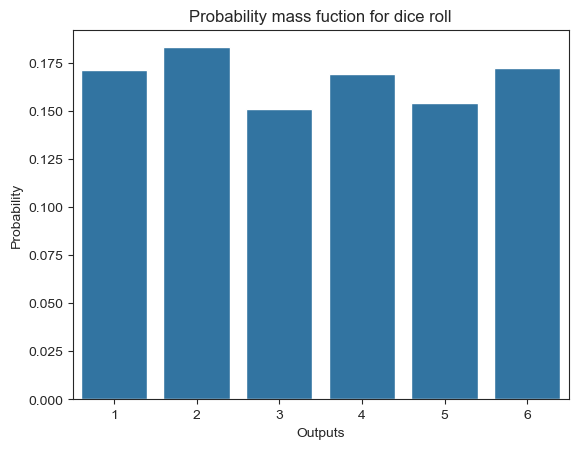

In [22]:
# plot graph 

sns.barplot(x= pmf.index,y = pmf)
plt.xlabel("Outputs")
plt.ylabel("Probability")
plt.title("Probability mass fuction for dice roll")

probability for sum when two dice roll

In [25]:
s = pd.Series(np.random.randint(1,7,1000) + np.random.randint(1,7,1000))
pmf = s.value_counts()/len(s)
pmf.sort_index(inplace=True)
pmf

2     0.028
3     0.056
4     0.077
5     0.108
6     0.136
7     0.156
8     0.134
9     0.116
10    0.091
11    0.065
12    0.033
Name: count, dtype: float64

<Axes: xlabel='None', ylabel='count'>

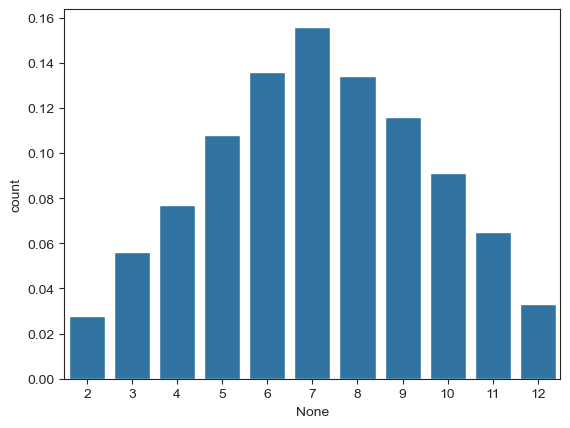

In [26]:
sns.barplot(x = pmf.index , y = pmf)

`Cumulative Distribution function(cdf) for pmf`
- probability that a random variable is less than or equal to specific value.
- how much the prob has been covered up to this point. 

In [31]:
pmf

2     0.028
3     0.056
4     0.077
5     0.108
6     0.136
7     0.156
8     0.134
9     0.116
10    0.091
11    0.065
12    0.033
Name: count, dtype: float64

In [36]:
cdf = pmf.cumsum()
cdf  # start - 0 (or greater than 0) and ends with 1 (always) 

2     0.028
3     0.084
4     0.161
5     0.269
6     0.405
7     0.561
8     0.695
9     0.811
10    0.902
11    0.967
12    1.000
Name: count, dtype: float64

<Axes: xlabel='None', ylabel='count'>

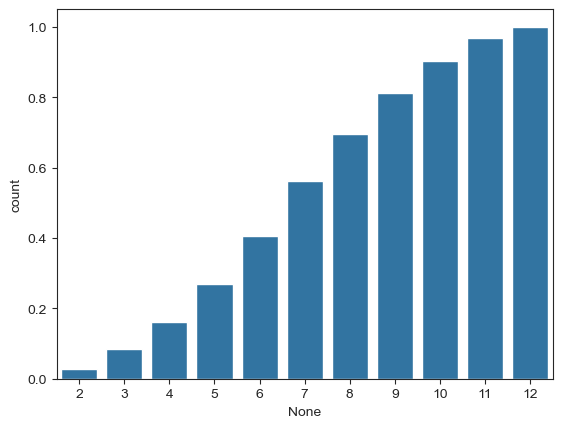

In [37]:
sns.barplot(x = cdf.index , y = cdf )

prob of sum coming between 4 and 10 --> cdf(10) - cdf(4)
$$
 p\left(4 < X < 10\right) =  cdf\left(10\right) - cdf\left(4\right)

$$

In [41]:
cdf_between_4_and_10 = cdf[10] - cdf[4]
print(f"prob that the random variable will come between 4 and 10 is : {cdf_between_4_and_10*100 : .2f}%")

prob that the random variable will come between 4 and 10 is :  74.10%


`Probability Density Function (pdf)`
- probability estimation
    - parametric probability estimation 
        - distribution pattern is known
    - non-parametric probability estimation

mean of normal data :  49.982214642235064


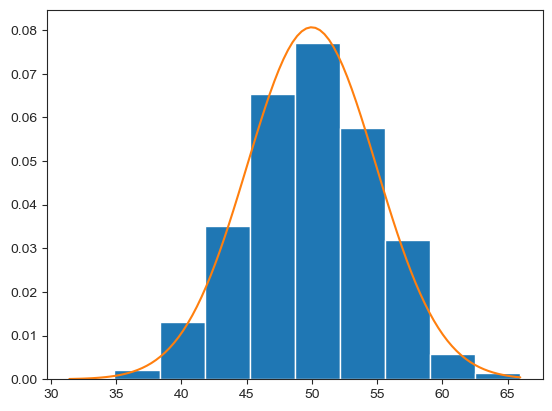

In [52]:
# parametric probability estimation

# normal distribution data
normal_data = np.random.normal(loc=50, scale=5, size=1000)

print('mean of normal data : ',normal_data.mean())
# calculate sample mean and std
normal_mean = normal_data.mean()
normal_std = normal_data.std()

# fit the distribution with the above parameters
dist = stats.norm(normal_mean, normal_std)

values = np.linspace(normal_data.min(),normal_data.max(), 100)

probabilities = [dist.pdf(value) for value in values]

plt.hist(normal_data,density=True)
plt.plot(values, probabilities)
plt.show()

<Axes: ylabel='Count'>

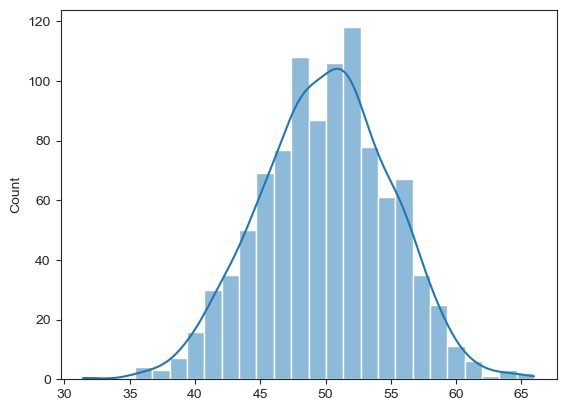

In [53]:
# using sns
sns.histplot(normal_data,kde=True)

non-parametric density estimation 
**kernel density estimation**

In [57]:
# generating sample 
sample1 = np.random.normal(loc = 20, scale = 5 , size = 400)
sample2 = np.random.normal(loc = 40, scale = 5, size = 600)
sample = np.hstack((sample1, sample2))

[]

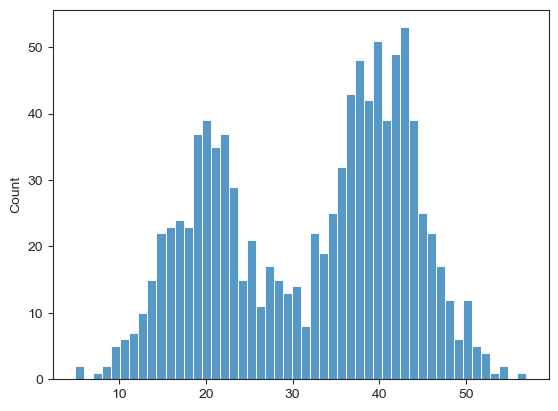

In [59]:
sns.histplot(sample,bins=50)
plt.plot()

In [ ]:
from sklearn.neighbors import KernelDensity
model = KernelDensity(bandwidth=5, kernel='gaussian')

# convert sample data into 2d --> because most of the ml algorithm models work with 2d data 
sample = sample.reshape((len(sample),1))
model.fit(sample)   # made kernel and calculated y values by adding point of each gaussion dist 

,bandwidth,5
,algorithm,'auto'
,kernel,'gaussian'
,metric,'euclidean'
,atol,0
,rtol,0
,breadth_first,True
,leaf_size,40
,metric_params,None


In [72]:
values = np.linspace(sample.min(),sample.max(),100)
values = values.reshape((len(values),1))

In [73]:
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)

returns the log-density estimate of the input samples values. This is because the method of the
KernelDensity class returns the logarithm of the probability density estimate rather than the actual probability density estimate.

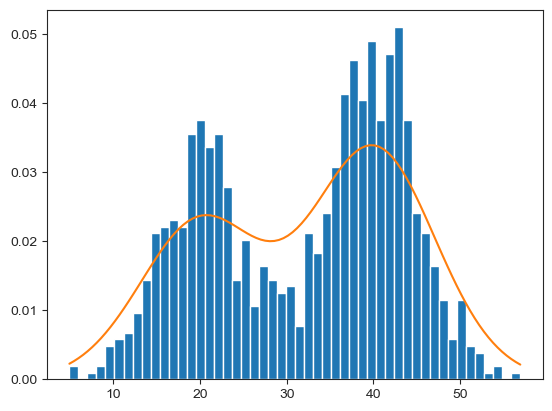

In [79]:
plt.hist(sample, bins=50, density=True)
plt.plot(values, probabilities)
plt.show()

you can play with the bandwidth also 

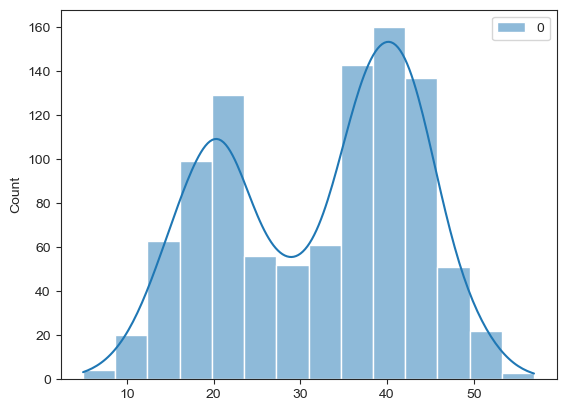

In [ ]:
# alternative
sns.histplot(sample, kde=True)
plt.show()

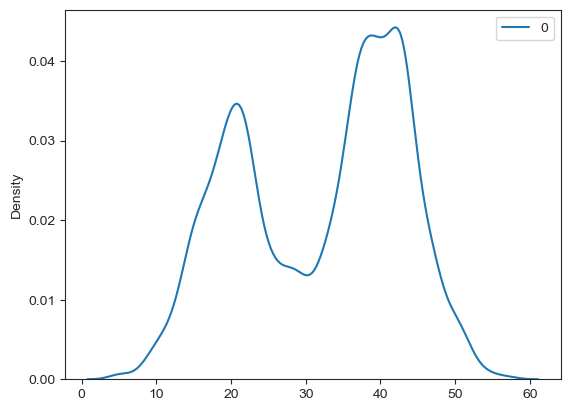

In [84]:
sns.kdeplot(sample,bw_adjust=0.5)
plt.show()